In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.datasets import load_wine

wine = load_wine()

In [5]:
print(type(wine))

<class 'sklearn.utils._bunch.Bunch'>


In [6]:
print(wine.data)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]


In [7]:
print(wine.feature_names)

['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [8]:
print(wine.target_names)

['class_0' 'class_1' 'class_2']


In [9]:
wine.data.shape

(178, 13)

In [10]:
df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

df['target'] = wine.target

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [13]:
print(df['target'].value_counts())

target
1    71
0    59
2    48
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [17]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
tree_predicitions = tree.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, tree_predicitions)

print(f"Accuracy Score: ", accuracy)

Accuracy Score:  0.9444444444444444


In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, tree_predicitions))

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [21]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, tree_predicitions))

[[11  1  0]
 [ 0 14  0]
 [ 0  1  9]]


In [26]:
for depth in range(1, 21):
  model = DecisionTreeClassifier(
      max_depth=depth,
      random_state=42
  )

  model.fit(X_train, y_train)

  predictions = model.predict(X_test)
  train_predictions = model.predict(X_train)

  accuracy = accuracy_score(y_test, predictions)
  train_accuracy = accuracy_score(y_train, train_predictions)
  print(model.get_depth())
  print(f"Depth: {depth}, Test Accuracy: {accuracy:.4f}, Train Accuracy: {train_accuracy:.4f}")

1
Depth: 1, Test Accuracy: 0.5833, Train Accuracy: 0.6620
2
Depth: 2, Test Accuracy: 0.8611, Train Accuracy: 0.9366
3
Depth: 3, Test Accuracy: 0.9444, Train Accuracy: 0.9930
4
Depth: 4, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 5, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 6, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 7, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 8, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 9, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 10, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 11, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 12, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 13, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 14, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 15, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 16, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Depth: 17, Test Accuracy: 0.9444, Train Accuracy: 1.0000
4
Dept

In [27]:
from sklearn.tree import plot_tree


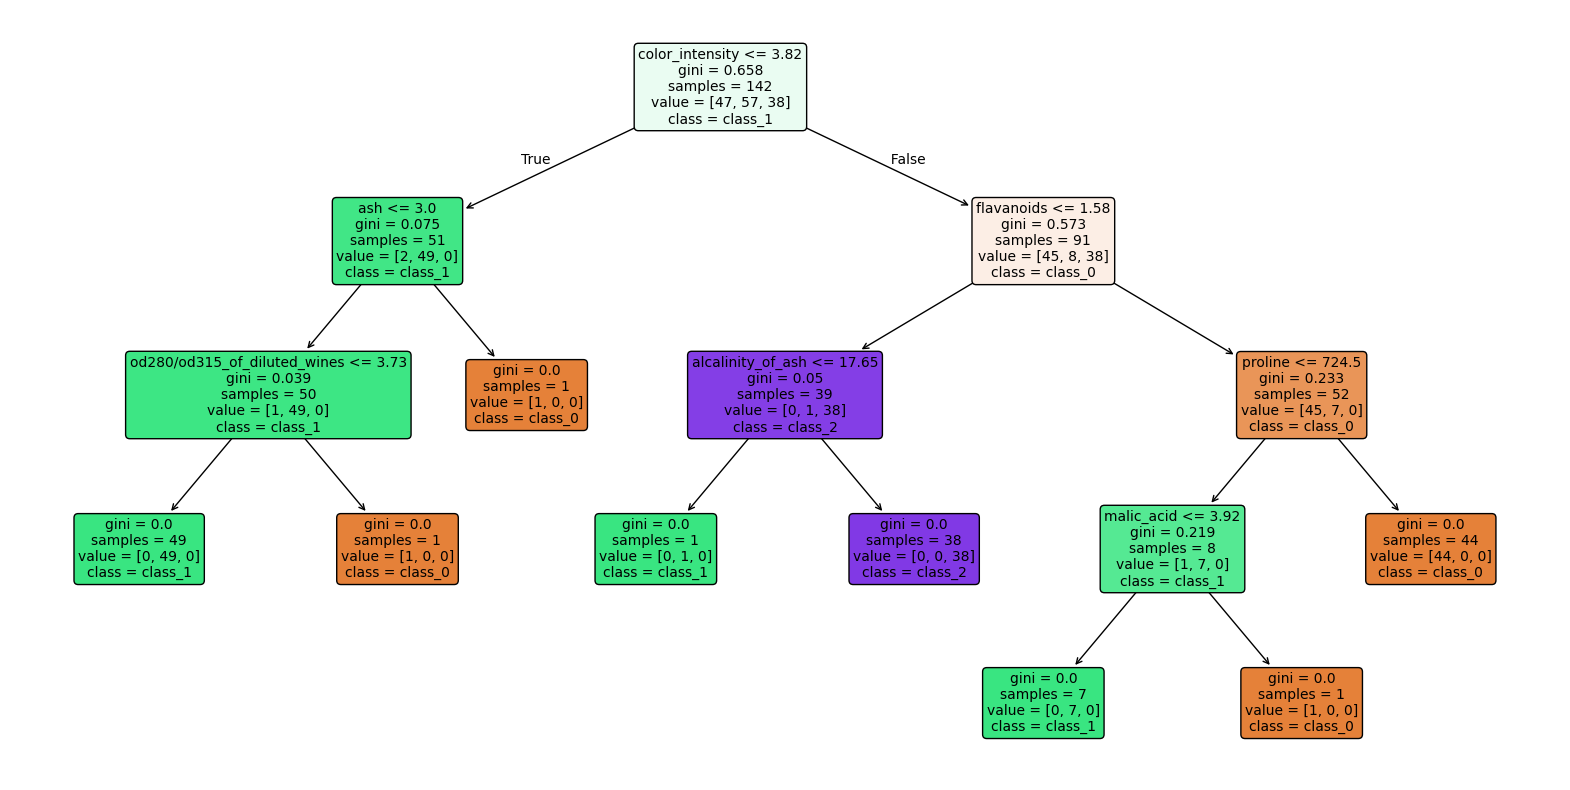

In [28]:
plt.figure(figsize=(20, 10))
plot_tree(
    tree,
    feature_names=wine.feature_names,
    class_names=wine.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.show()

In [29]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": wine.feature_names,
    "Importance": tree.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                         Feature  Importance
6                     flavanoids    0.408073
9                color_intensity    0.400189
12                       proline    0.110985
11  od280/od315_of_diluted_wines    0.020986
3              alcalinity_of_ash    0.020865
2                            ash    0.020163
1                     malic_acid    0.018738
4                      magnesium    0.000000
0                        alcohol    0.000000
8                proanthocyanins    0.000000
7           nonflavanoid_phenols    0.000000
5                  total_phenols    0.000000
10                           hue    0.000000
